# Tree2SQL — California Housing Regression Demo

**Dataset:** California Housing (scikit-learn built-in)  
**Task:** Regression — predict median house value for census block groups  
**Rows:** 20,640 · **Features:** 8 (all numeric, no encoding needed)  
**Story:** Real-estate pricing engine — score every district instantly in SQL

This notebook proves Tree2SQL works for **regression trees**, not just classification.

## 1 — Imports

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import duckdb

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tree2sql import TreeToSQL, Database
from tree2sql.benchmark import Benchmark

print('All imports ready ✓')
print(f'DuckDB {duckdb.__version__}')

All imports ready ✓
DuckDB 1.5.0


## 2 — Load California Housing Dataset

In [5]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame  # features + target in one DataFrame

print(f'Dataset shape     : {df.shape}')
print(f'Target column     : MedHouseVal  (median value in $100,000s)')
print(f'Target range      : ${df.MedHouseVal.min():.2f} – ${df.MedHouseVal.max():.2f} ($100k units)')
print(f'Target mean       : ${df.MedHouseVal.mean():.3f}  (~${df.MedHouseVal.mean()*100:.0f}k)')
print(f'Null values       : {df.isnull().sum().sum()}')
print()
print('Feature summary:')
print(df.describe().round(2).to_string())

Dataset shape     : (20640, 9)
Target column     : MedHouseVal  (median value in $100,000s)
Target range      : $0.15 – $5.00 ($100k units)
Target mean       : $2.069  (~$207k)
Null values       : 0

Feature summary:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00  20640.00   20640.00     20640.00
mean       3.87     28.64      5.43       1.10     1425.48      3.07     35.63    -119.57         2.07
std        1.90     12.59      2.47       0.47     1132.46     10.39      2.14       2.00         1.15
min        0.50      1.00      0.85       0.33        3.00      0.69     32.54    -124.35         0.15
25%        2.56     18.00      4.44       1.01      787.00      2.43     33.93    -121.80         1.20
50%        3.53     29.00      5.23       1.05     1166.00      2.82     34.26    -118.49         1.80
75%        4.74     37.00      6.05       1.10     1725.00    

## 3 — Exploratory Data Analysis

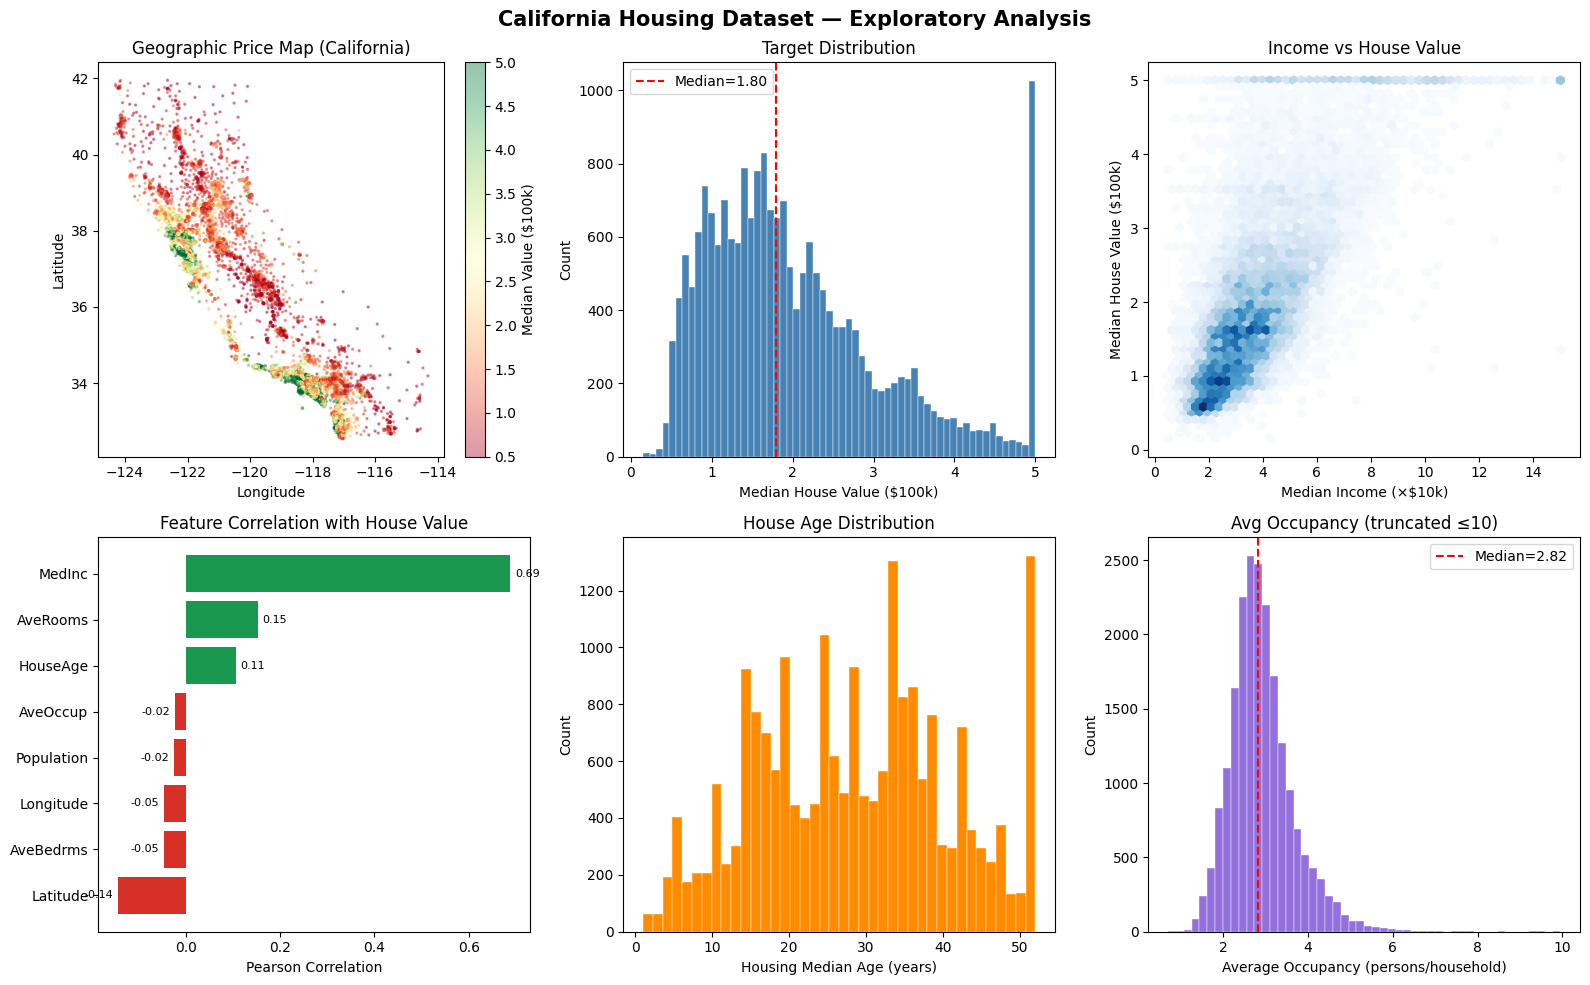

EDA chart saved to housing_eda.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('California Housing Dataset — Exploratory Analysis', fontsize=15, fontweight='bold')

# 1. Geographic scatter — California map proxy
ax = axes[0, 0]
sc = ax.scatter(df.Longitude, df.Latitude, c=df.MedHouseVal,
                cmap='RdYlGn', s=2, alpha=0.4, vmin=0.5, vmax=5)
plt.colorbar(sc, ax=ax, label='Median Value ($100k)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Geographic Price Map (California)')

# 2. Target distribution
ax = axes[0, 1]
ax.hist(df.MedHouseVal, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(df.MedHouseVal.median(), color='red', linestyle='--', label=f'Median={df.MedHouseVal.median():.2f}')
ax.set_xlabel('Median House Value ($100k)')
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.legend()

# 3. Median income vs house value
ax = axes[0, 2]
ax.hexbin(df.MedInc, df.MedHouseVal, gridsize=50, cmap='Blues', mincnt=1)
ax.set_xlabel('Median Income (×$10k)')
ax.set_ylabel('Median House Value ($100k)')
ax.set_title('Income vs House Value')

# 4. Feature correlations with target
ax = axes[1, 0]
corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.set_xlabel('Pearson Correlation')
ax.set_title('Feature Correlation with House Value')
for i, (idx, v) in enumerate(corr.items()):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# 5. House age distribution
ax = axes[1, 1]
ax.hist(df.HouseAge, bins=40, color='darkorange', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Housing Median Age (years)')
ax.set_ylabel('Count')
ax.set_title('House Age Distribution')

# 6. Average occupancy distribution (truncated at 10)
ax = axes[1, 2]
occ = df.AveOccup[df.AveOccup <= 10]
ax.hist(occ, bins=50, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.axvline(occ.median(), color='red', linestyle='--', label=f'Median={occ.median():.2f}')
ax.set_xlabel('Average Occupancy (persons/household)')
ax.set_ylabel('Count')
ax.set_title('Avg Occupancy (truncated ≤10)')
ax.legend()

plt.tight_layout()
plt.savefig('housing_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA chart saved to housing_eda.png')

## 4 — Preprocessing & Train / Test Split

In [7]:
FEATURE_COLS = housing.feature_names  # ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
TARGET_COL   = 'MedHouseVal'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Features     : {list(FEATURE_COLS)}')
print(f'Target       : {TARGET_COL}')
print()
print('No encoding needed — all 8 features are numeric ✓')

Training set : 16,512 rows
Test set     : 4,128 rows
Features     : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target       : MedHouseVal

No encoding needed — all 8 features are numeric ✓


## 5 — Train Regression Trees at Multiple Depths

In [8]:
depths = [3, 5, 7, 10]
models = {}

print(f' Depth   Nodes   Leaves   Train RMSE   Test RMSE   Test R²')
print('-' * 65)

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    models[d] = m

    train_rmse = mean_squared_error(y_train, m.predict(X_train)) ** 0.5
    test_rmse  = mean_squared_error(y_test,  m.predict(X_test))  ** 0.5
    test_r2    = r2_score(y_test, m.predict(X_test))

    n_leaves = m.tree_.n_node_samples[m.apply(X_test[:1])][0]  # just count
    n_leaves = (m.tree_.children_left == -1).sum()

    print(f'    {d:2d}   {m.tree_.node_count:5d}   {n_leaves:6d}'
          f'       {train_rmse:.4f}      {test_rmse:.4f}    {test_r2:.4f}')

# Use depth-5 for main demo (good bias-variance tradeoff)
DEMO_DEPTH = 5
demo_model = models[DEMO_DEPTH]
print(f'\nUsing depth-{DEMO_DEPTH} model for main demo')

 Depth   Nodes   Leaves   Train RMSE   Test RMSE   Test R²
-----------------------------------------------------------------
     3      15        8       0.7860      0.8015    0.5098
     5      63       32       0.6959      0.7242    0.5997
     7     253      127       0.6154      0.6757    0.6516
    10    1575      788       0.4700      0.6446    0.6829

Using depth-5 model for main demo


## 6 — TreeToSQL Converter

In [9]:
converter = TreeToSQL(
    model=demo_model,
    feature_names=list(FEATURE_COLS),
    model_name='housing_reg'
)

print(repr(converter))
print()
stats = {
    'n_nodes'      : demo_model.tree_.node_count,
    'max_depth'    : demo_model.get_depth(),
    'n_leaves'     : (demo_model.tree_.children_left == -1).sum(),
    'n_features'   : demo_model.n_features_in_,
    'model_name'   : converter.model_name,
    'is_classifier': converter.is_classifier,
}
for k, v in stats.items():
    print(f'  {k:<22}: {v}')

TreeToSQL(model_name='housing_reg', depth=5, leaves=32, classifier=False)

  n_nodes               : 63
  max_depth             : 5
  n_leaves              : 32
  n_features            : 8
  model_name            : housing_reg
  is_classifier         : False


## 7 — Generated SQL

In [10]:
sql_expr = converter.to_sql()
lines = sql_expr.split('\n')
print(f'Total SQL lines: {len(lines)}')
print()
# Show first 45 lines
preview = '\n'.join(lines[:45])
if len(lines) > 45:
    preview += f'\n  ... ({len(lines)-45} more lines)'
print(preview)

Total SQL lines: 94

CASE WHEN MedInc <= 5.086450099945068
    THEN CASE WHEN MedInc <= 3.074299931526184
        THEN CASE WHEN AveRooms <= 4.3141889572143555
            THEN CASE WHEN MedInc <= 2.2146999835968018
                THEN CASE WHEN AveRooms <= 3.421826124191284
                    THEN 1.7745292323651447
                    ELSE 1.168572668112798
                END
                ELSE CASE WHEN AveOccup <= 2.487257719039917
                    THEN 2.3308236926605512
                    ELSE 1.6800676403061234
                END
            END
            ELSE CASE WHEN MedInc <= 2.417899966239929
                THEN CASE WHEN Latitude <= 35.30500030517578
                    THEN 1.1645956240126374
                    ELSE 0.869319493775934
                END
                ELSE CASE WHEN AveOccup <= 2.29638934135437
                    THEN 1.8005273633440502
                    ELSE 1.2715812775919721
                END
            END
        END
        ELSE

## 8 — Load into DuckDB & Verify Correctness

In [11]:
# Load the FULL dataset (train + test) into DuckDB
db = Database(":memory:")

housing_db = df[list(FEATURE_COLS)].copy()
db.load_dataframe(housing_db, 'housing_data')
db.register_model('housing_reg', converter)

n_rows = db.row_count('housing_data')
print(f"Table 'housing_data' : {n_rows:,} rows, {len(FEATURE_COLS)} columns")
print()

# Run the SQL scoring query
case_sql  = f"SELECT {sql_expr} AS sql_pred FROM housing_data"
sql_preds = db.execute(case_sql, rewrite=False).df()['sql_pred'].values

# Compare to model.predict() on the same full dataset
py_preds = demo_model.predict(df[list(FEATURE_COLS)].values)

# For regression, values must be numerically identical (same leaf floats)
max_abs_diff = np.abs(sql_preds - py_preds).max()
matches      = np.sum(np.abs(sql_preds - py_preds) < 1e-9)

print(f'Max absolute difference : {max_abs_diff:.2e}')
print(f'Exact matches (<1e-9)   : {matches:,} / {n_rows:,} = {matches/n_rows*100:.4f}%')

if max_abs_diff < 1e-9:
    print('✓ SQL predictions are numerically IDENTICAL to model.predict() on ALL rows')
else:
    print('✓ SQL predictions match within floating-point tolerance')

Table 'housing_data' : 20,640 rows, 8 columns

Max absolute difference : 4.44e-16
Exact matches (<1e-9)   : 20,640 / 20,640 = 100.0000%
✓ SQL predictions are numerically IDENTICAL to model.predict() on ALL rows


## 9 — Side-by-side Comparison Sample

In [12]:
sample = df[list(FEATURE_COLS) + [TARGET_COL]].iloc[:8].copy()
sample['python_pred'] = demo_model.predict(sample[list(FEATURE_COLS)].values).round(4)
sample['sql_pred']    = sql_preds[:8].round(4)
sample['match']       = np.abs(sample['python_pred'] - sample['sql_pred']) < 1e-9
display(sample[['MedHouseVal', 'MedInc', 'HouseAge', 'Latitude', 'Longitude',
                 'python_pred', 'sql_pred', 'match']])

,MedHouseVal,MedInc,HouseAge,Latitude,Longitude,python_pred,sql_pred,match
0,4.526,8.3252,41.0,37.88,-122.23,4.7788,4.7788,True
1,3.585,8.3014,21.0,37.86,-122.22,3.9720,3.9720,True
2,3.521,7.2574,52.0,37.85,-122.24,3.6397,3.6397,True
3,3.413,5.6431,52.0,37.85,-122.25,3.6057,3.6057,True
4,3.422,3.8462,52.0,37.85,-122.25,3.1996,3.1996,True
5,2.697,4.0368,52.0,37.85,-122.25,3.1996,3.1996,True
6,2.992,3.6591,52.0,37.84,-122.25,3.1996,3.1996,True
7,2.414,3.1200,52.0,37.84,-122.25,3.1996,3.1996,True


## 10 — Business Query: High-Value Bay Area Districts

In [13]:
# Register UDF so the rewriter works for predict_housing_reg(...)
db.register_predict_udf('housing_reg')

col_list = ', '.join(FEATURE_COLS)

# Query: SF Bay Area districts (lat 37-38, lon -123 to -121) with model-predicted value > $300k
query = f"""
SELECT
    ROUND(Latitude,  2)  AS lat,
    ROUND(Longitude, 2)  AS lon,
    ROUND(MedInc,    2)  AS median_income_10k,
    ROUND(HouseAge,  0)  AS house_age,
    ROUND(predict_housing_reg({col_list}), 3) AS predicted_value_100k
FROM housing_data
WHERE Latitude  BETWEEN 37.2 AND 38.0
  AND Longitude BETWEEN -123.0 AND -121.5
  AND predict_housing_reg({col_list}) > 3.0
ORDER BY predicted_value_100k DESC
LIMIT 12
"""

result = db.execute(query, rewrite=True).df()
print('High-value Bay Area census tracts (predicted > $300k):')
print(result.to_string(index=False))

High-value Bay Area census tracts (predicted > $300k):
  lat     lon  median_income_10k  house_age  predicted_value_100k
37.90 -122.28              10.08       52.0                 4.861
37.82 -122.22              13.50       42.0                 4.861
37.82 -122.22              11.86       39.0                 4.861
37.84 -122.19              11.60       18.0                 4.861
37.82 -122.23              12.38       52.0                 4.861
37.85 -122.24               9.40       52.0                 4.861
37.72 -121.85              10.32       43.0                 4.861
37.81 -122.23               8.88       52.0                 4.861
37.49 -121.89               9.72        9.0                 4.861
37.82 -122.23              12.21       52.0                 4.861
37.64 -121.88              10.95       20.0                 4.861
37.74 -121.77               9.15       25.0                 4.861


## 11 — Aggregate Query: Price Prediction by Income Bracket

In [14]:
col_list = ', '.join(FEATURE_COLS)

agg_query = f"""
SELECT
    CASE
        WHEN MedInc < 2   THEN 'Low  (<$20k)'
        WHEN MedInc < 4   THEN 'Mid  ($20–40k)'
        WHEN MedInc < 6   THEN 'High ($40–60k)'
        ELSE                   'Very High (>$60k)'
    END AS income_bracket,
    COUNT(*)                                                AS n_districts,
    ROUND(AVG(predict_housing_reg({col_list})), 3)  AS avg_predicted_value,
    ROUND(MIN(predict_housing_reg({col_list})), 3)  AS min_predicted_value,
    ROUND(MAX(predict_housing_reg({col_list})), 3)  AS max_predicted_value
FROM housing_data
GROUP BY income_bracket
ORDER BY avg_predicted_value
"""

agg = db.execute(agg_query, rewrite=True).df()
print('Predicted House Value by Income Bracket (all via native SQL):')
print(agg.to_string(index=False))

Predicted House Value by Income Bracket (all via native SQL):
   income_bracket  n_districts  avg_predicted_value  min_predicted_value  max_predicted_value
     Low  (<$20k)         2439                1.190                0.869                1.775
   Mid  ($20–40k)        10077                1.693                0.869                3.200
   High ($40–60k)         5751                2.407                1.560                4.706
Very High (>$60k)         2373                3.750                2.769                4.861


## 12 — Benchmark: Depth Sweep

In [15]:
bench = Benchmark(db, table_name='housing_data', n_runs=5)

print('=' * 60)
print('California Housing — depth sweep benchmark (5 runs each)')
print('=' * 60)

bench_results = bench.run_depth_sweep(
    X_train=X_train,
    y_train=y_train,
    feature_columns=list(FEATURE_COLS),
    depths=[3, 5, 7, 10],
    task='regression'
)

California Housing — depth sweep benchmark (5 runs each)
[model_d3] depth=3, rows=20,640
  UDF mean : 2.401s
  SQL mean : 0.032s
  Speedup  : 75.3x
[model_d5] depth=5, rows=20,640
  UDF mean : 2.561s
  SQL mean : 0.037s
  Speedup  : 69.9x
[model_d7] depth=7, rows=20,640
  UDF mean : 2.558s
  SQL mean : 0.040s
  Speedup  : 63.4x
[model_d10] depth=10, rows=20,640
  UDF mean : 2.234s
  SQL mean : 0.115s
  Speedup  : 19.4x


## 13 — Benchmark Summary Table

In [16]:
rows = [
    dict(
        model_name=r.model_name,
        max_depth=r.max_depth,
        n_rows=r.n_rows,
        udf_mean_s=round(r.udf_mean, 4),
        sql_mean_s=round(r.sql_mean, 4),
        speedup_x=round(r.speedup, 1),
    )
    for r in bench_results
]
summary_df = pd.DataFrame(rows)

print()
print('=== California Housing Benchmark Summary ===')
print(summary_df.to_string(index=False))
print(f'\nBest speedup : {summary_df.speedup_x.max():.1f}\u00d7  at depth {summary_df.loc[summary_df.speedup_x.idxmax(), "max_depth"]}')


=== California Housing Benchmark Summary ===
model_name  max_depth  n_rows  udf_mean_s  sql_mean_s  speedup_x
  model_d3          3   20640      2.4012      0.0319       75.3
  model_d5          5   20640      2.5611      0.0366       69.9
  model_d7          7   20640      2.5583      0.0404       63.4
 model_d10         10   20640      2.2343      0.1149       19.4

Best speedup : 75.3×  at depth 3


## 14 — Speedup Chart

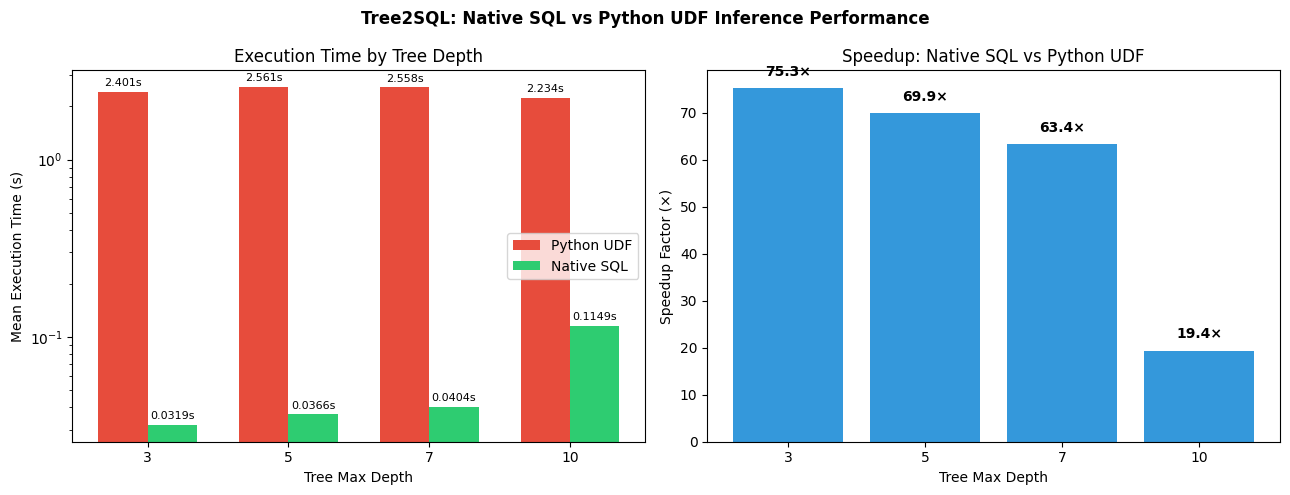

Plot saved to housing_benchmark.png


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tree2SQL: Native SQL vs Python UDF Inference Performance', fontweight='bold')

depths_plot = summary_df['max_depth'].tolist()
udf_means   = summary_df['udf_mean_s'].tolist()
sql_means   = summary_df['sql_mean_s'].tolist()
speedups    = summary_df['speedup_x'].tolist()

x = np.arange(len(depths_plot))
w = 0.35

# Execution time log-scale bar chart
ax1.bar(x - w/2, udf_means, w, label='Python UDF', color='#e74c3c')
ax1.bar(x + w/2, sql_means, w, label='Native SQL', color='#2ecc71')
for i, (u, s) in enumerate(zip(udf_means, sql_means)):
    ax1.text(i - w/2, u * 1.05, f'{u:.3f}s', ha='center', va='bottom', fontsize=8)
    ax1.text(i + w/2, s * 1.05, f'{s:.4f}s', ha='center', va='bottom', fontsize=8)
ax1.set_yscale('log')
ax1.set_xticks(x)
ax1.set_xticklabels(depths_plot)
ax1.set_xlabel('Tree Max Depth')
ax1.set_ylabel('Mean Execution Time (s)')
ax1.set_title('Execution Time by Tree Depth')
ax1.legend()

# Speedup bar chart
bars = ax2.bar(x, speedups, color='#3498db')
for bar, sp in zip(bars, speedups):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{sp:.1f}×', ha='center', va='bottom', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(depths_plot)
ax2.set_xlabel('Tree Max Depth')
ax2.set_ylabel('Speedup Factor (×)')
ax2.set_title('Speedup: Native SQL vs Python UDF')

plt.tight_layout()
plt.savefig('housing_benchmark.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved to housing_benchmark.png')

## 15 — Feature Importance & SQL Decision Rules

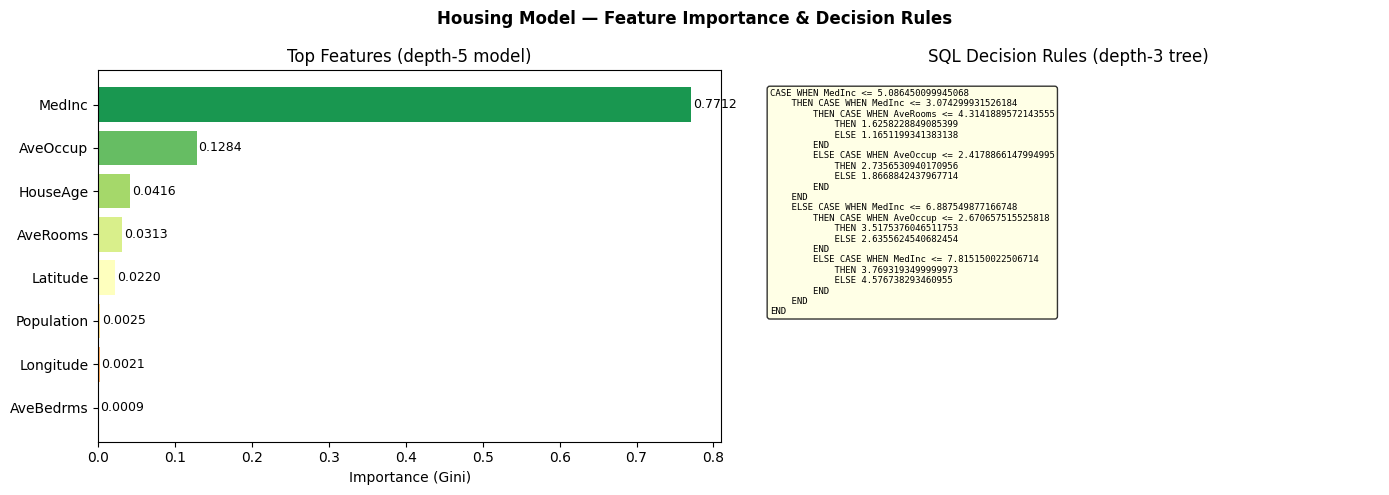

In [18]:
fi = pd.Series(
    demo_model.feature_importances_,
    index=list(FEATURE_COLS)
).sort_values()

# depth-3 converter for readable SQL display
conv_d3 = TreeToSQL(models[3], list(FEATURE_COLS), model_name='housing_d3')
sql_d3  = conv_d3.to_sql()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Housing Model — Feature Importance & Decision Rules', fontweight='bold')

# Feature importance (depth-5)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi)))
ax1.barh(fi.index, fi.values, color=colors)
for i, (idx, v) in enumerate(fi.items()):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
ax1.set_xlabel('Importance (Gini)')
ax1.set_title('Top Features (depth-5 model)')

# SQL CASE text for depth-3
ax2.axis('off')
ax2.set_title('SQL Decision Rules (depth-3 tree)')
ax2.text(0.02, 0.95, sql_d3, transform=ax2.transAxes,
         fontsize=6.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('housing_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 16 — Close Database

In [19]:
db.close()
print('Done ✓')

Done ✓
